In [1]:
# ============================================================
# STEP 1: Import Required Libraries
# Load all libraries needed for data processing and ML
# ============================================================

import pandas as pd
import glob

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [2]:
# ============================================================
# STEP 2: Merge All CSV Files from the 'triple' Folder
# Combine the 15 smart grid experiment datasets into one file
# ============================================================
# path to your folder
path = "Downloads/triple/*.csv"

# get all csv files
files = glob.glob(path)

print("Files found:", len(files))

df_list = []

for file in files:
    df = pd.read_csv(file)
    df_list.append(df)

# merge all datasets
merged_data = pd.concat(df_list, ignore_index=True)

print("Merged dataset shape:", merged_data.shape)

# save merged dataset
merged_data.to_csv("smart_grid_merged.csv", index=False)

Files found: 15
Merged dataset shape: (78377, 129)


In [3]:
# ============================================================
# STEP 3: Inspect the Label Distribution
# Check how many samples belong to each class
# ============================================================
print(merged_data["marker"].value_counts())
print(merged_data.head())
print(merged_data["marker"].value_counts())

marker
Attack      55663
Natural     18309
NoEvents     4405
Name: count, dtype: int64
   R1-PA1:VH     R1-PM1:V  R1-PA2:VH     R1-PM2:V   R1-PA3:VH     R1-PM3:V  \
0  70.399324  127673.0908 -49.572308  127648.0176 -169.578319  127723.2374   
1  73.688102  130280.7109 -46.300719  130255.6377 -166.278082  130355.9307   
2  73.733939  130305.7842 -46.254883  130280.7109 -166.232245  130381.0040   
3  74.083443  130581.5902 -45.899649  130556.5169 -165.882741  130656.8100   
4  74.553268  131083.0556 -45.424094  131057.9823 -165.424375  131158.2754   

   R1-PA4:IH   R1-PM4:I  R1-PA5:IH   R1-PM5:I  ...  control_panel_log4  \
0  65.689611  605.91099 -57.003571  626.78553  ...                   0   
1  71.831719  483.59351 -50.947407  500.98896  ...                   0   
2  71.808800  483.59351 -50.913030  500.98896  ...                   0   
3  72.152575  482.86107 -50.437475  499.15786  ...                   0   
4  72.118198  484.50906 -50.013486  497.69298  ...                   0   


In [4]:
# ============================================================
# STEP 4: Remove Log Columns
# These contain control system and network logs that are not
# useful for the initial ML model
# ============================================================

log_columns = [
"control_panel_log1","control_panel_log2","control_panel_log3","control_panel_log4",
"relay1_log","relay2_log","relay3_log","relay4_log",
"snort_log1","snort_log2","snort_log3","snort_log4"
]

data = merged_data.drop(columns=log_columns)

print("Dataset shape after removing logs:", data.shape)

Dataset shape after removing logs: (78377, 117)


In [5]:
# ============================================================
# STEP 5: Convert Labels to Numeric Values
# Machine learning models require numeric labels
# ============================================================

data["marker"] = data["marker"].map({
"NoEvents":0,
"Natural":1,
"Attack":2
})

print(data["marker"].value_counts())

marker
2    55663
1    18309
0     4405
Name: count, dtype: int64


In [6]:
# ============================================================
# STEP 6: Check for Missing Values
# Verify that the dataset does not contain null values
# ============================================================

print("Total missing values:", data.isnull().sum().sum())

Total missing values: 0


In [7]:
# ============================================================
# STEP 7: Separate Input Features (X) and Labels (y)
# X contains all grid measurements, y contains class labels
# ============================================================

X = data.drop("marker", axis=1)
y = data["marker"]

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (78377, 116)
Label vector shape: (78377,)


In [8]:
# ============================================================
# STEP 8: Clean Invalid Numeric Values
# Replace infinite values and extremely large numbers
# ============================================================

import numpy as np

# replace positive and negative infinity with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# check how many NaN values exist
print("Total NaN values:", X.isnull().sum().sum())

# replace NaN values with column median
X = X.fillna(X.median())

print("Remaining NaN values:", X.isnull().sum().sum())

Total NaN values: 10906
Remaining NaN values: 0


In [9]:
# ============================================================
# STEP 9: Normalize Feature Values
# Standardize sensor measurements for ML models
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
# ============================================================
# STEP 10: Split Dataset into Training and Testing Sets
# Use 80% of data for training and 20% for testing
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 62701
Testing samples: 15676


In [11]:
# ============================================================
# STEP 11: Train Random Forest Classifier
# This will be our baseline cyber attack detection model
# ============================================================

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
# ============================================================
# STEP 12: Generate Predictions on the Test Set
# ============================================================

predictions = model.predict(X_test)

In [13]:
# ============================================================
# STEP 13: Evaluate Model Performance
# Print precision, recall, and F1-score
# ============================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      0.94      0.96       881
           1       0.93      0.75      0.83      3662
           2       0.92      0.98      0.95     11133

    accuracy                           0.92     15676
   macro avg       0.94      0.89      0.91     15676
weighted avg       0.92      0.92      0.92     15676



In [14]:
# Quick interpretation:
#| Class | Meaning  | Recall   | What it means                         |
#| ----- | -------- | -------- | ------------------------------------- |
#| 0     | NoEvents |   0.94   | Normal grid detected well             |
#| 1     | Natural  |   0.75   | Disturbances sometimes confused       |
#| 2     | Attack   |   0.98   | Cyber attacks detected extremely well |

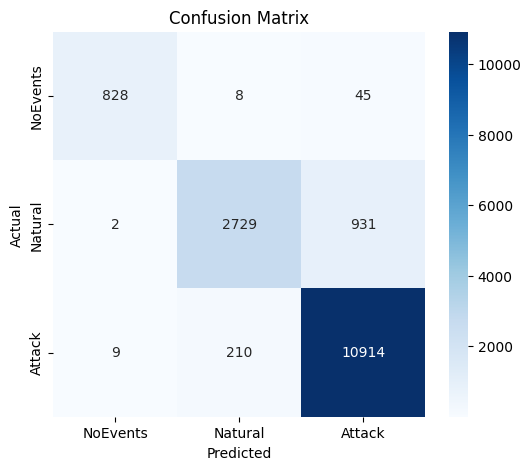

In [15]:
# ============================================================
# STEP 14: Confusion Matrix
# Visualize model prediction errors
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NoEvents","Natural","Attack"],
            yticklabels=["NoEvents","Natural","Attack"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
# ============================================================
# STEP 15: Feature Importance Analysis
# Identify which sensors contribute most to predictions
# ============================================================

import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

R4-PM2:V    0.022649
R1-PM2:V    0.019677
R2-PA:ZH    0.019415
R3-PA:ZH    0.018744
R4-PM7:V    0.017982
R3-PM2:V    0.017958
R4-PA:ZH    0.016616
R1-PA:ZH    0.015450
R2-PM5:I    0.014162
R2-PM1:V    0.013974
dtype: float64


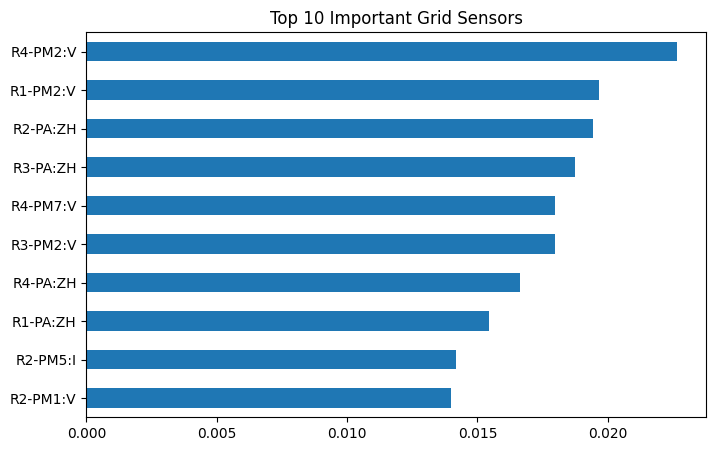

In [17]:
# ============================================================
# STEP 16: Plot Top 10 Important Features
# ============================================================

feature_importance.head(10).plot(
    kind="barh",
    figsize=(8,5),
    title="Top 10 Important Grid Sensors"
)

plt.gca().invert_yaxis()
plt.show()

In [18]:
# ============================================================
# STEP 17: Train Isolation Forest for Anomaly Detection
# Detect cyber attacks without explicit attack labels
# ============================================================

from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.1,
    random_state=42
)

iso_model.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [19]:
# 1 = normal
#-1 = anomaly 

# ============================================================
# STEP 18: Predict Anomalies
# ============================================================

anomaly_preds = iso_model.predict(X_test)

# convert format
anomaly_preds = [1 if x == -1 else 0 for x in anomaly_preds]

print("Total anomalies detected:", sum(anomaly_preds))

Total anomalies detected: 1626


In [20]:
# STEP 19 — Autoencoder Neural Network
# Now we build a deep learning anomaly detector.

# !pip install torch

In [21]:
# ============================================================
# STEP 20: Build Autoencoder Neural Network
# Learn compressed representation of normal grid behavior
# ============================================================

import torch
import torch.nn as nn

input_dim = X_train.shape[1]

class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


model_auto = Autoencoder()

In [22]:
# ============================================================
# STEP 21: Train Autoencoder
# ============================================================

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_auto.parameters(), lr=0.001)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

for epoch in range(20):

    optimizer.zero_grad()

    outputs = model_auto(X_train_tensor)

    loss = criterion(outputs, X_train_tensor)

    loss.backward()

    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.9967
Epoch 2, Loss: 0.9933
Epoch 3, Loss: 0.9900
Epoch 4, Loss: 0.9867
Epoch 5, Loss: 0.9832
Epoch 6, Loss: 0.9795
Epoch 7, Loss: 0.9754
Epoch 8, Loss: 0.9710
Epoch 9, Loss: 0.9661
Epoch 10, Loss: 0.9606
Epoch 11, Loss: 0.9545
Epoch 12, Loss: 0.9478
Epoch 13, Loss: 0.9403
Epoch 14, Loss: 0.9321
Epoch 15, Loss: 0.9232
Epoch 16, Loss: 0.9134
Epoch 17, Loss: 0.9028
Epoch 18, Loss: 0.8914
Epoch 19, Loss: 0.8792
Epoch 20, Loss: 0.8662


In [23]:
# ============================================================
# STEP 22: Detect Anomalies with Autoencoder
# ============================================================

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

reconstructions = model_auto(X_test_tensor)

mse = ((X_test_tensor - reconstructions) ** 2).mean(axis=1)

threshold = mse.mean() + 2 * mse.std()

auto_preds = (mse > threshold).int()

print("Detected anomalies:", auto_preds.sum())

Detected anomalies: tensor(287)


In [24]:
# ============================================================
# STEP 23: Create Time Sequences for LSTM
# ============================================================
# Smart grid data is sequential, so LSTM models can learn patterns over time.

import numpy as np

def create_sequences(X, y, seq_length=10):

    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])

    return np.array(X_seq), np.array(y_seq)


X_seq, y_seq = create_sequences(X_scaled, y.values)

In [25]:
# ============================================================
# STEP 24: LSTM Model for Time-Series Attack Detection
# ============================================================

class LSTMModel(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.lstm = nn.LSTM(input_dim, 64, batch_first=True)

        self.fc = nn.Linear(64, 3)

    def forward(self, x):

        _, (h, _) = self.lstm(x)

        return self.fc(h[-1])


lstm_model = LSTMModel(X_seq.shape[2])

In [26]:
# ============================================================
# STEP 25: Simulate Real-Time Attack Detection
# Process data stream sequentially
# ============================================================

for i in range(100):

    sample = X_test[i].reshape(1, -1)

    pred = model.predict(sample)

    if pred == 2:
        print(f"⚠️ Cyber attack detected at timestep {i}")

    elif pred == 1:
        print(f"Grid disturbance detected at timestep {i}")

    else:
        print(f"Normal grid operation at timestep {i}")

⚠️ Cyber attack detected at timestep 0
⚠️ Cyber attack detected at timestep 1
⚠️ Cyber attack detected at timestep 2
⚠️ Cyber attack detected at timestep 3
Grid disturbance detected at timestep 4
Normal grid operation at timestep 5
⚠️ Cyber attack detected at timestep 6
Grid disturbance detected at timestep 7
⚠️ Cyber attack detected at timestep 8
⚠️ Cyber attack detected at timestep 9
Grid disturbance detected at timestep 10
⚠️ Cyber attack detected at timestep 11
⚠️ Cyber attack detected at timestep 12
⚠️ Cyber attack detected at timestep 13
Grid disturbance detected at timestep 14
Grid disturbance detected at timestep 15
⚠️ Cyber attack detected at timestep 16
⚠️ Cyber attack detected at timestep 17
⚠️ Cyber attack detected at timestep 18
⚠️ Cyber attack detected at timestep 19
⚠️ Cyber attack detected at timestep 20
⚠️ Cyber attack detected at timestep 21
Grid disturbance detected at timestep 22
⚠️ Cyber attack detected at timestep 23
Grid disturbance detected at timestep 24
⚠️ Cyb

In [27]:
# ============================================================
# STEP 26: Install SHAP library for Explainable AI
# ============================================================

# !pip install shap

In [28]:
# ============================================================
# STEP 27: Import SHAP for model explainability
# ============================================================

import shap

In [36]:
# ============================================================
# STEP 28: Create SHAP explainer
# ============================================================
# We explain why the model predicts attacks.

# convert scaled data back to dataframe so we keep feature names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_sample = X_scaled_df.sample(50, random_state=42)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    X_sample,
    approximate=True
)

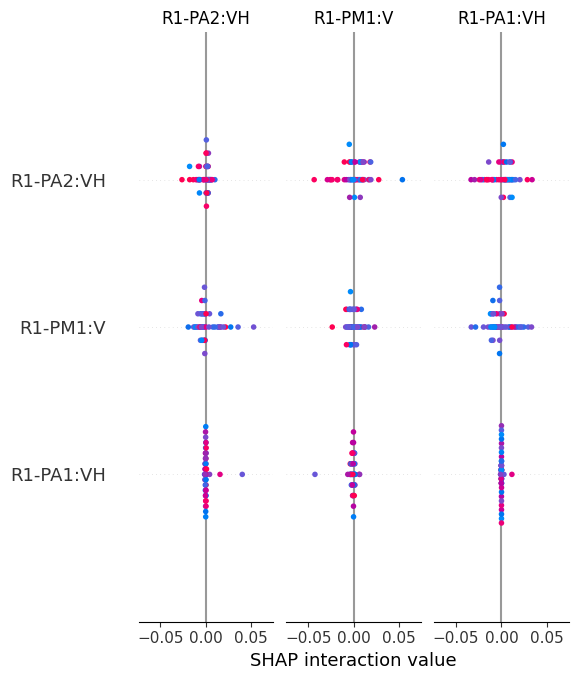

In [41]:
# ============================================================
# STEP 29: Global feature importance visualization
# ============================================================

shap.summary_plot(shap_values, X_sample)

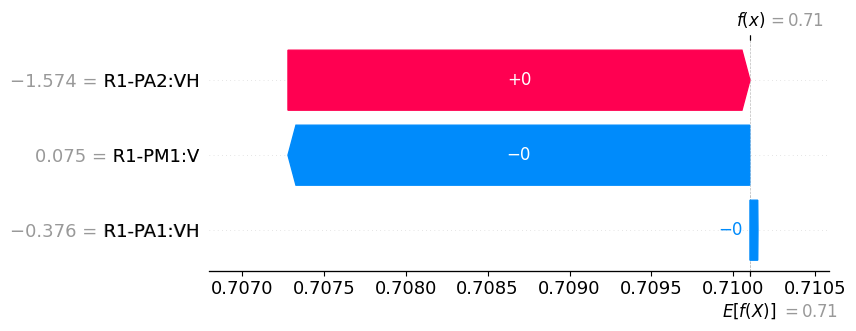

In [54]:
# ============================================================
# STEP 30: Explain one prediction
# ============================================================

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[2][0],             # SHAP values for attack class
        base_values=explainer.expected_value[2],
        data=X_sample.iloc[0],
        feature_names=X_sample.columns
    )
)

In [52]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[2].shape)
print(X_sample.shape)

<class 'numpy.ndarray'>
50
(116, 3)
(50, 116)


In [44]:
# ============================================================
# STEP 31: Prepare data for Autoencoder training
# ============================================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [45]:
# ============================================================
# STEP 32: Build Autoencoder model
# ============================================================

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation="relu")(input_layer)
encoded = Dense(32, activation="relu")(encoded)

decoded = Dense(64, activation="relu")(encoded)
decoded = Dense(input_dim, activation="sigmoid")(decoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 116)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           7,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 116)                 │           7,540 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,220 (75.08 KB)

 Trainable params: 19,220 (75.08 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# ============================================================
# STEP 33: Train autoencoder using normal grid data
# ============================================================

normal_data = X_scaled[y == 2]   # assuming class 2 = normal

autoencoder.fit(
    normal_data,
    normal_data,
    epochs=20,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/20
783/783 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0112 - val_loss: 0.0034
Epoch 2/20
783/783 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0027 - val_loss: 0.0021
Epoch 3/20
783/783 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 4/20
783/783 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 5/20
783/783 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 6/20
783/783 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 7/20
783/783 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 8/20
783/783 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 9.7755e-04 - val_loss: 9.2832e-04
Epoch 9/20
783/783 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 9.1296e-04 - val_loss: 8.8851e-04
Epoch 10/20
783/783 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8.5905e-04 - val_loss: 8.3114e-04
Epoch 11/20
783/783 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8.1352e-04 - val_loss: 7.8691e-04
Epoch 12/20
78

In [47]:
# ============================================================
# STEP 34: Reconstruct sensor readings
# ============================================================

reconstructed = autoencoder.predict(X_scaled)

2450/2450 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step


In [48]:
# ============================================================
# STEP 35: Calculate reconstruction error
# ============================================================

import numpy as np

reconstruction_error = np.mean(
    np.square(X_scaled - reconstructed),
    axis=1
)

print("Average Reconstruction Error:", reconstruction_error.mean())

Average Reconstruction Error: 0.0005827702618444159


In [50]:
# ============================================================
# STEP 36: Self-healing data correction
# ============================================================

corrected_data = reconstructed
corrected_data = scaler.inverse_transform(corrected_data)

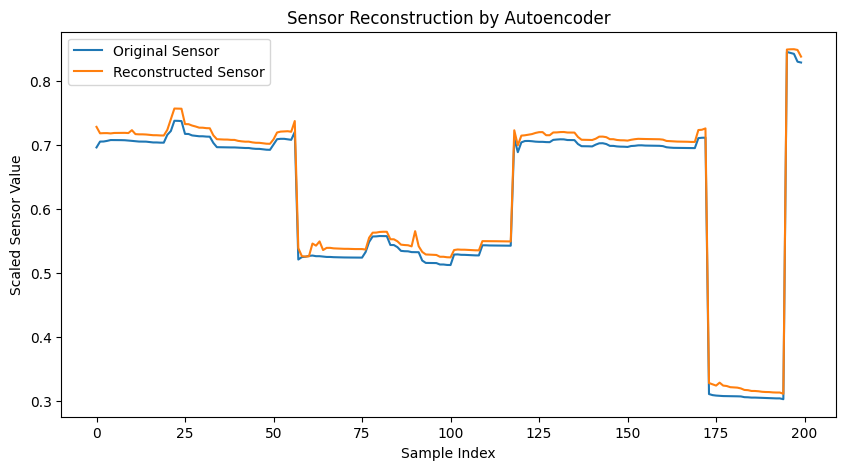

In [55]:
# ============================================================
# STEP 37: Visualize Original vs Reconstructed Sensor Values
# ============================================================

import matplotlib.pyplot as plt

sensor_index = 0  # choose any feature index

plt.figure(figsize=(10,5))

plt.plot(X_scaled[:200, sensor_index], label="Original Sensor")
plt.plot(reconstructed[:200, sensor_index], label="Reconstructed Sensor")

plt.title("Sensor Reconstruction by Autoencoder")
plt.xlabel("Sample Index")
plt.ylabel("Scaled Sensor Value")

plt.legend()
plt.show()

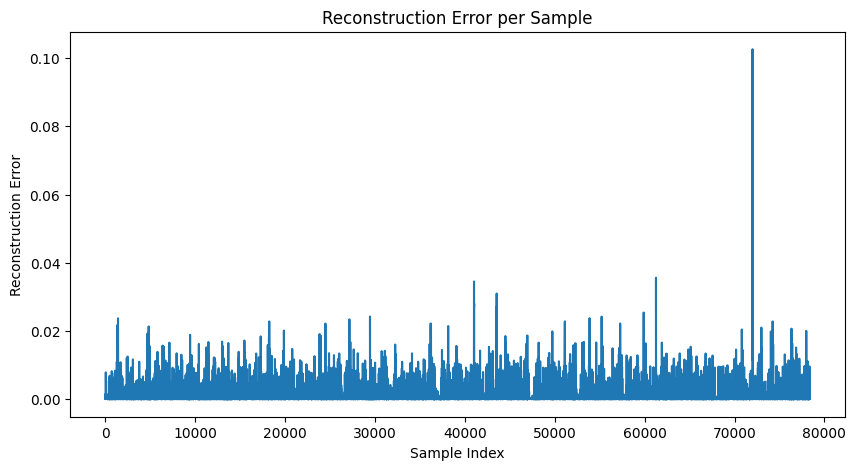

In [56]:
# ============================================================
# STEP 38: Plot Reconstruction Error Across Samples
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(reconstruction_error)

plt.title("Reconstruction Error per Sample")
plt.xlabel("Sample Index")
plt.ylabel("Reconstruction Error")

plt.show()

In [57]:
# ============================================================
# STEP 39: Simulate False Data Injection Attack
# ============================================================

corrupted_data = X_scaled.copy()

# introduce fake sensor spike
corrupted_data[50:60, 5] = corrupted_data[50:60, 5] * 5

In [58]:
# ============================================================
# STEP 40: Autoencoder Repairs Corrupted Data
# ============================================================

repaired_data = autoencoder.predict(corrupted_data)

2450/2450 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step


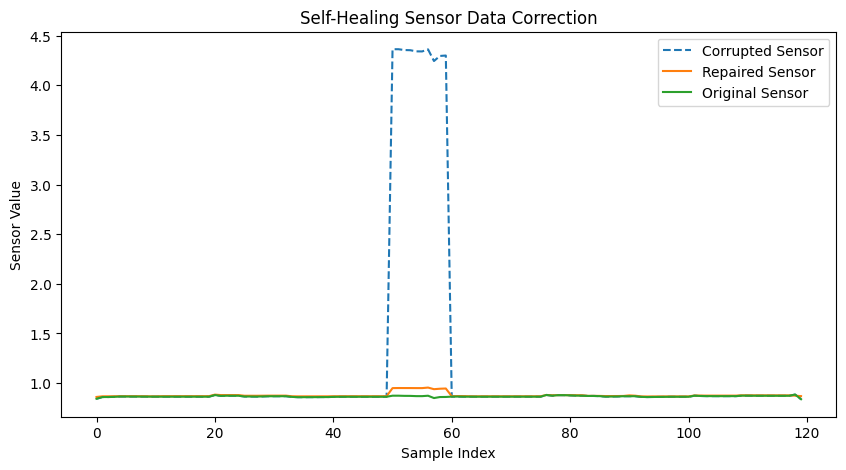

In [59]:
# ============================================================
# STEP 41: Visualize Self-Healing Data Correction
# ============================================================

sensor_index = 5

plt.figure(figsize=(10,5))

plt.plot(corrupted_data[:120, sensor_index], label="Corrupted Sensor", linestyle="dashed")
plt.plot(repaired_data[:120, sensor_index], label="Repaired Sensor")
plt.plot(X_scaled[:120, sensor_index], label="Original Sensor")

plt.title("Self-Healing Sensor Data Correction")
plt.xlabel("Sample Index")
plt.ylabel("Sensor Value")

plt.legend()
plt.show()

In [ ]:
"""
# Results: Self-Healing Sensor Data Correction

This experiment demonstrates the effectiveness of the proposed AI-based self-healing framework 
for detecting and correcting corrupted smart grid sensor data.

# False Data Injection Attack Simulation

A simulated False Data Injection Attack (FDIA) was introduced by artificially amplifying the values 
of a selected sensor between sample indices 50 and 60.  
This created a large spike in the corrupted signal that significantly deviated from the normal operating range.

# Observed Signals

Original Sensor Signal (Green)
Represents the true measurement from the grid sensor during normal operation.  
The signal remains stable within the normal range of approximately 0.85-0.9.

Corrupted Sensor Signal (Blue, Dashed)
Represents the sensor readings after the simulated attack.  
A large abnormal spike appears between sample indices 50-60, reaching values above 4.0.

Repaired Sensor Signal (Orange)  
Represents the signal reconstructed by the trained autoencoder model.  
Instead of reproducing the corrupted spike, the model generates values close to the normal range.

# Interpretation

The visualization demonstrates that the autoencoder successfully learned the normal behavioral patterns.  
When exposed to corrupted input data, the model reconstructs a corrected signal that closely matches expected behavior.

# Key Outcome

The results illustrate the feasibility of using an AI-based reconstruction model as a self-healing mechanism.  
It can mitigate the effects of False Data Injection Attacks by replacing abnormal sensor values with reconstructed estimates.
"""